# GalaxyLens: Galaxy Simulation and Weak Lensing Analysis

This project focuses on simulating **spiral and elliptical galaxies** and demonstrating the effects of **Point Spread Function (PSF) blurring**, **observational noise**, and **weak gravitational lensing shear**.

The project is organized into **two parts**:

## Part 1 – Galaxy Simulation and Visualization
- Generate realistic spiral and elliptical galaxies using **GalSim**.  
- Apply PSF convolution and Gaussian/Poisson noise to mimic observational conditions.  
- Apply a small weak lensing shear to demonstrate its visual effect.  
- Save the resulting galaxy images as **FITS files** and **PNG visualizations** for inspection.

## Part 2 – Quantitative Shape Analysis
- Measure galaxy shapes using adaptive moments to obtain **ellipticity (e)** and **shear components (g1, g2)**.  
- Store measurements in a CSV file for reproducibility.  
- Perform statistical visualizations (histograms, scatter plots, boxplots) to quantify the effect of PSF, noise, and shear on galaxy shapes.  
- Interpret the results to validate the applied weak lensing effects.

This two-part workflow provides a **complete pipeline**, from realistic galaxy simulation to **numerical analysis of shapes**, offering both **visual and quantitative insights** into weak lensing effects.


# Part 1 – Galaxy Simulation and Visualization

In this part, we simulate **spiral and elliptical galaxies** and demonstrate the effects of **Point Spread Function (PSF) blurring**, **observational noise**, and **weak lensing shear**.



In [ ]:
!pip install numpy matplotlib astropy galsim pandas


In this step, we set up the Python environment by installing required packages such as galsim, numpy, matplotlib, and astropy. These libraries will allow us to simulate galaxies, handle FITS images, and visualize results.

In [ ]:
!pip install seaborn


Here we create spiral and elliptical galaxies with random properties (flux, size, orientation). We then apply a PSF convolution to mimic telescope optics and add Gaussian noise to simulate realistic observations.

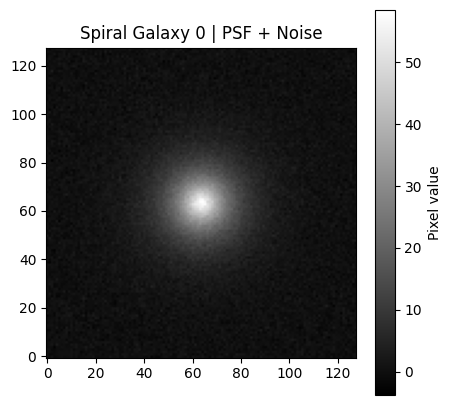

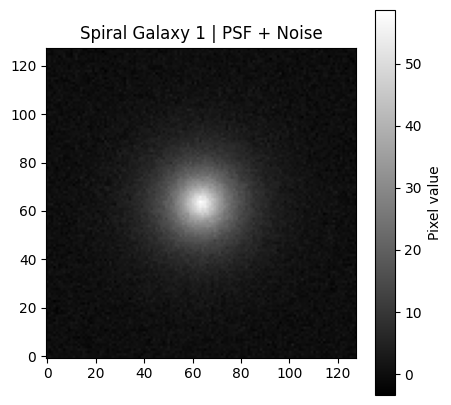

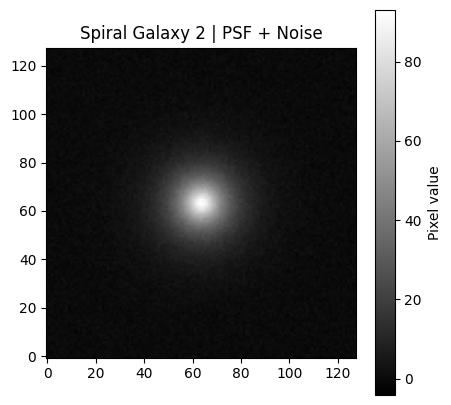

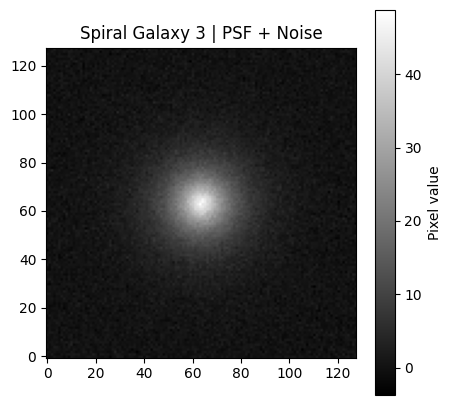

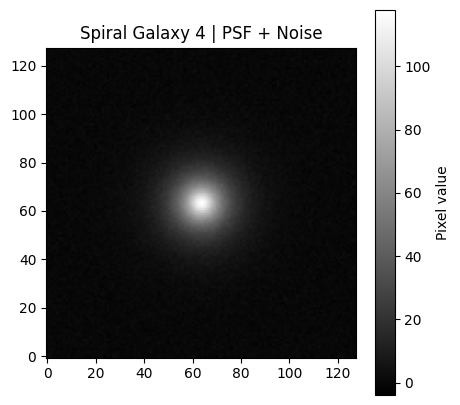

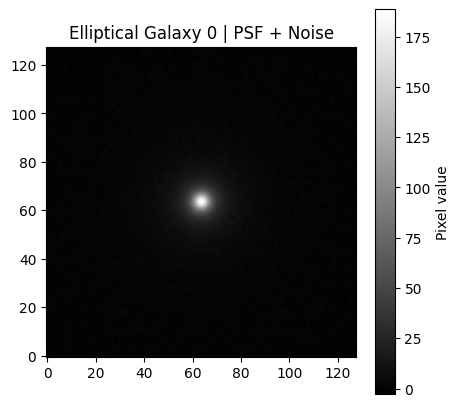

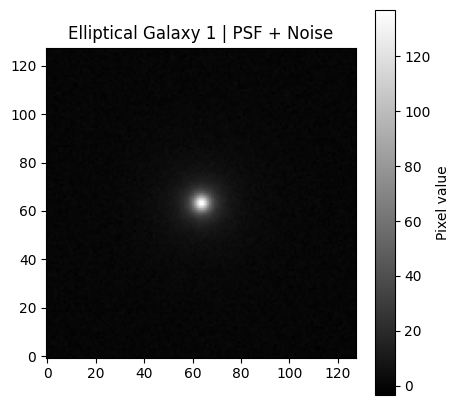

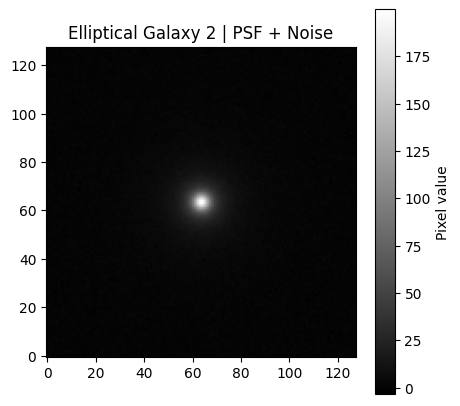

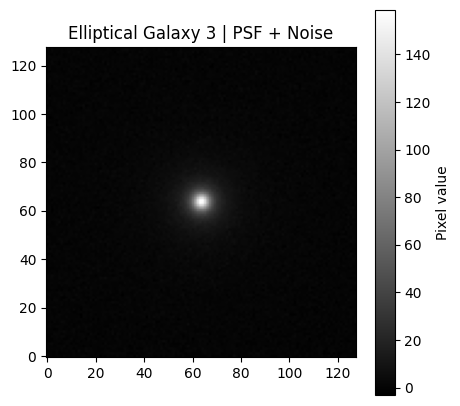

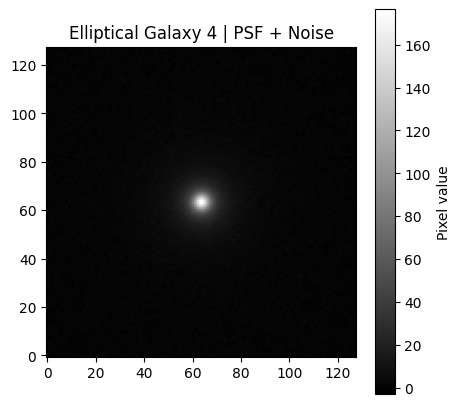

Saved PSF-convolved GSObjects for shear step.


In [ ]:
import galsim
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle  # <-- for saving GSObjects

# Directories
output_dir = "data/"
plots_dir = "plots/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Parameters
pixel_scale = 0.2
image_size = 128
flux_range = (3e4, 6e4)
noise_sigma = 1.0
psf_fwhm = 0.8
n_galaxies = 5

# Galaxy types
galaxy_types = [
    {"type": "spiral", "profile": galsim.Exponential},
    {"type": "elliptical", "profile": lambda **kwargs: galsim.Sersic(n=4, **kwargs)}
]

# Dictionary to save GSObjects for later shearing
psf_gal_dict = {}

# Loop over types and indices
for g in galaxy_types:
    for i in range(n_galaxies):
        flux = np.random.uniform(*flux_range)
        hlr = np.random.uniform(2.5, 4.0)

        # Generate raw galaxy
        raw_gal = g["profile"](half_light_radius=hlr, flux=flux)

        # Convolve with PSF
        psf = galsim.Gaussian(fwhm=psf_fwhm)
        psf_gal = galsim.Convolve([raw_gal, psf])

        # Draw image and add noise
        psf_image = psf_gal.drawImage(nx=image_size, ny=image_size, scale=pixel_scale)
        psf_image.addNoise(galsim.GaussianNoise(sigma=noise_sigma))

        # Save FITS
        fits_filename = f"{output_dir}{g['type']}_{i}_psf_noise.fits"
        psf_image.write(fits_filename)

        # Save plot
        plt.figure(figsize=(5,5))
        plt.imshow(psf_image.array, origin='lower', cmap='gray')
        plt.title(f"{g['type'].capitalize()} Galaxy {i} | PSF + Noise")
        plt.colorbar(label="Pixel value")
        plot_filename = f"{plots_dir}{g['type'].capitalize()}_{i}_psf_noise.png"
        plt.savefig(plot_filename)
        plt.show()
        plt.close()

        # Save the PSF-convolved GSObject for later shearing
        key = f"{g['type']}_{i}"
        psf_gal_dict[key] = psf_gal

# Save GSObjects dictionary
with open("data/psf_gal_objects.pkl", "wb") as f:
    pickle.dump(psf_gal_dict, f)

print("Saved PSF-convolved GSObjects for shear step.")



In thus step we will be applying a small weak lensing shear to the galaxies generated in Step 1, and saving the sheared images and plots.

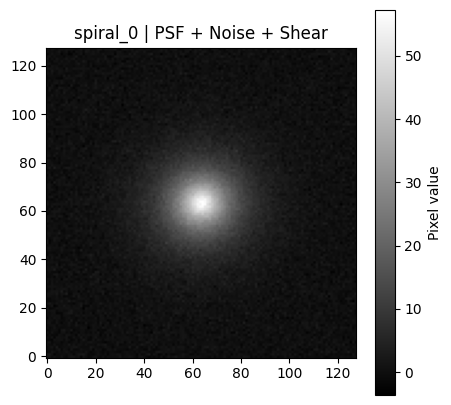

Saved sheared FITS: data/spiral_0_psf_noise_shear.fits | Saved plot: plots/spiral_0_psf_noise_shear.png


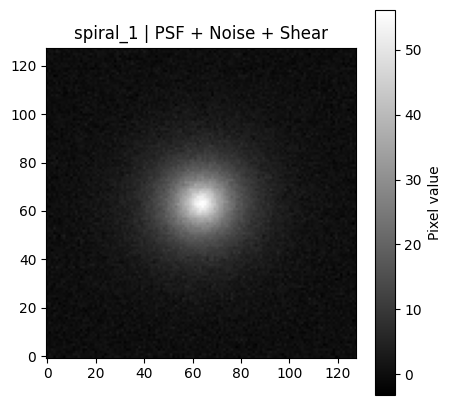

Saved sheared FITS: data/spiral_1_psf_noise_shear.fits | Saved plot: plots/spiral_1_psf_noise_shear.png


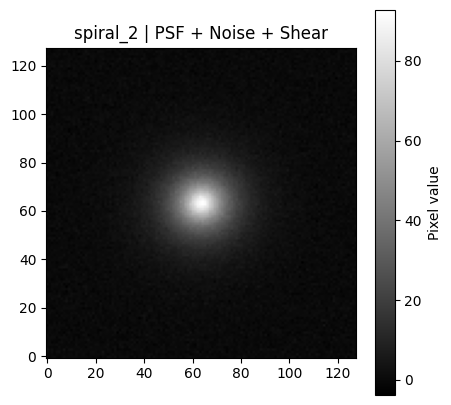

Saved sheared FITS: data/spiral_2_psf_noise_shear.fits | Saved plot: plots/spiral_2_psf_noise_shear.png


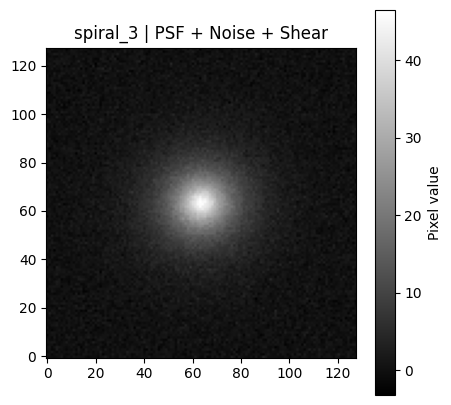

Saved sheared FITS: data/spiral_3_psf_noise_shear.fits | Saved plot: plots/spiral_3_psf_noise_shear.png


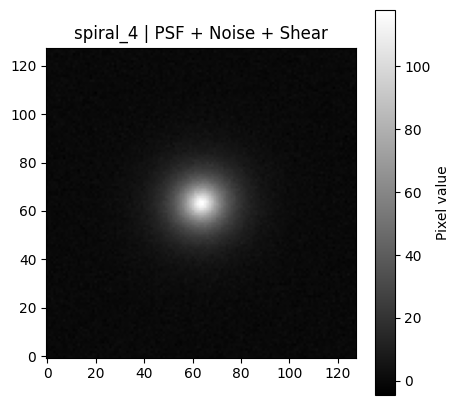

Saved sheared FITS: data/spiral_4_psf_noise_shear.fits | Saved plot: plots/spiral_4_psf_noise_shear.png


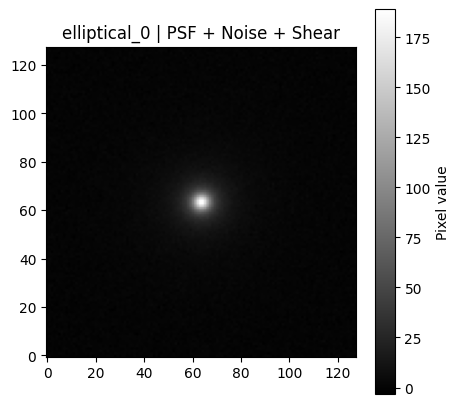

Saved sheared FITS: data/elliptical_0_psf_noise_shear.fits | Saved plot: plots/elliptical_0_psf_noise_shear.png


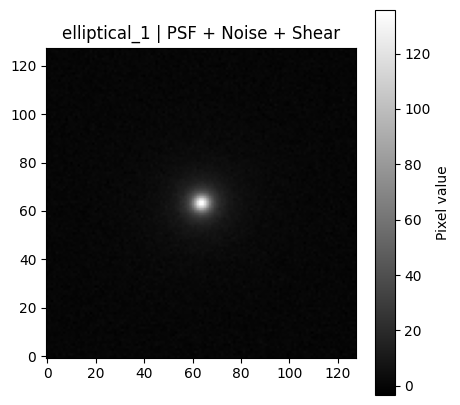

Saved sheared FITS: data/elliptical_1_psf_noise_shear.fits | Saved plot: plots/elliptical_1_psf_noise_shear.png


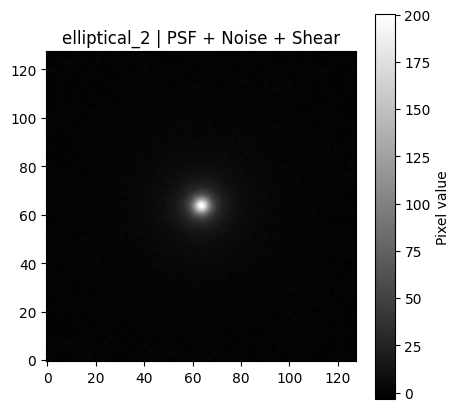

Saved sheared FITS: data/elliptical_2_psf_noise_shear.fits | Saved plot: plots/elliptical_2_psf_noise_shear.png


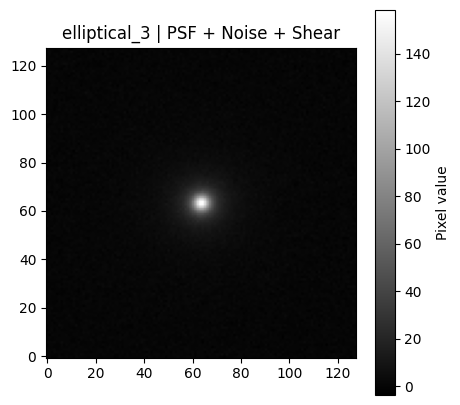

Saved sheared FITS: data/elliptical_3_psf_noise_shear.fits | Saved plot: plots/elliptical_3_psf_noise_shear.png


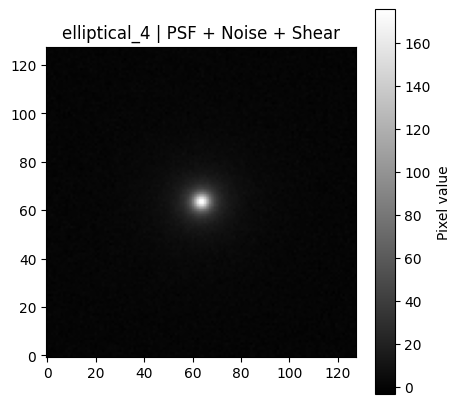

Saved sheared FITS: data/elliptical_4_psf_noise_shear.fits | Saved plot: plots/elliptical_4_psf_noise_shear.png


In [ ]:
# Part 1, Step 2: Apply Weak Lensing Shear to PSF-convolved galaxies

import galsim
import matplotlib.pyplot as plt
import os
import pickle  # for saving and loading GSObjects

# Directories
plots_dir = "plots/"
os.makedirs(plots_dir, exist_ok=True)
shear_output_dir = "data/"
os.makedirs(shear_output_dir, exist_ok=True)

# Shear parameters
shear_g1 = 0.02
shear_g2 = 0.01

# Load the PSF-convolved galaxy objects saved during Step 1
# (Assuming you saved them in Step 1 using pickle as a dictionary)
with open("data/psf_gal_objects.pkl", "rb") as f:
    psf_gal_dict = pickle.load(f)

# Loop over all galaxies
for key, psf_gal in psf_gal_dict.items():
    # Apply weak lensing shear
    sheared_gal = psf_gal.shear(g1=shear_g1, g2=shear_g2)

    # Draw the sheared galaxy
    sheared_image = sheared_gal.drawImage(nx=128, ny=128, scale=0.2)
    sheared_image.addNoise(galsim.GaussianNoise(sigma=1.0))

    # Save FITS
    sheared_fits = os.path.join(shear_output_dir, f"{key}_psf_noise_shear.fits")
    sheared_image.write(sheared_fits)

    # Save PNG plot
    plot_filename = os.path.join(plots_dir, f"{key}_psf_noise_shear.png")
    plt.figure(figsize=(5,5))
    plt.imshow(sheared_image.array, origin='lower', cmap='gray')
    plt.title(f"{key} | PSF + Noise + Shear")
    plt.colorbar(label="Pixel value")
    plt.savefig(plot_filename)
    plt.show()
    plt.close()

    print(f"Saved sheared FITS: {sheared_fits} | Saved plot: {plot_filename}")


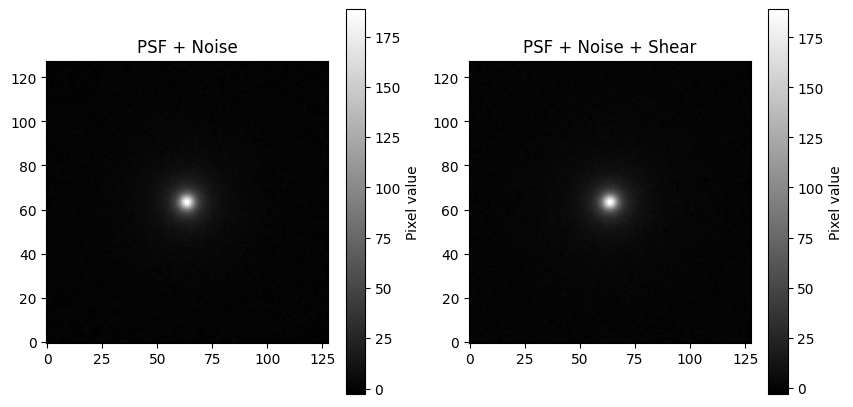

Saved comparison plot: plots_comparison/elliptical_0_comparison.png


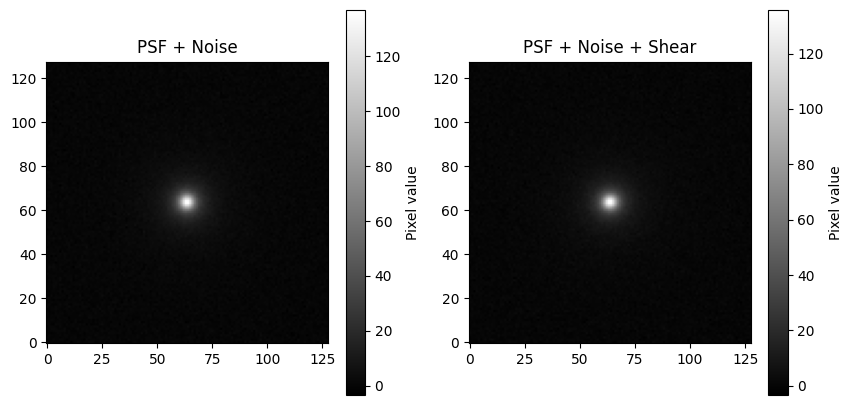

Saved comparison plot: plots_comparison/elliptical_1_comparison.png


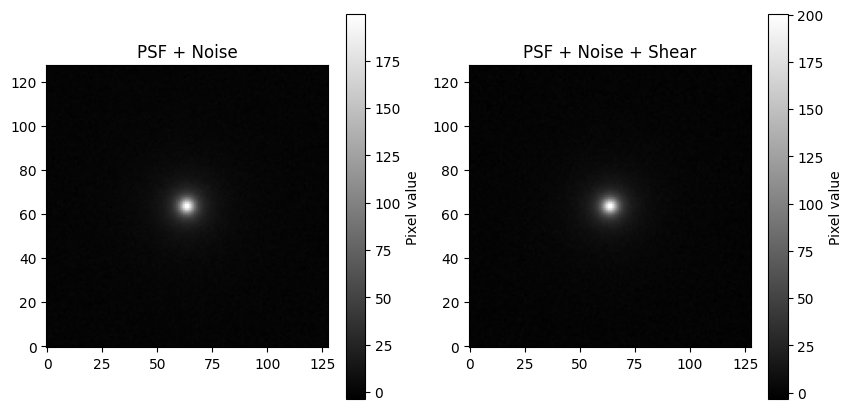

Saved comparison plot: plots_comparison/elliptical_2_comparison.png


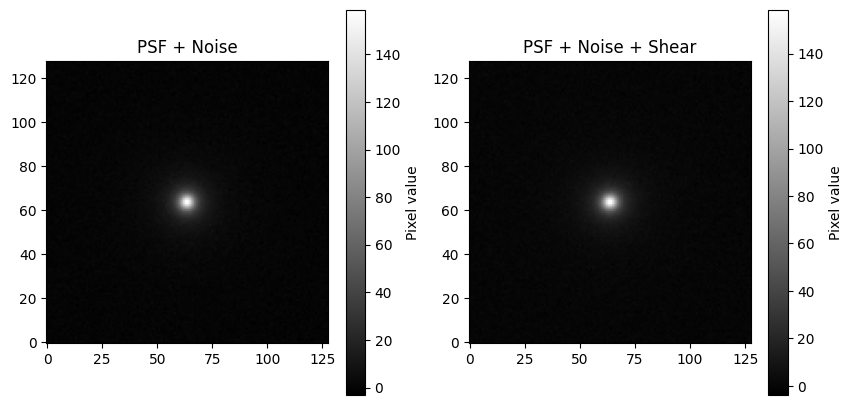

Saved comparison plot: plots_comparison/elliptical_3_comparison.png


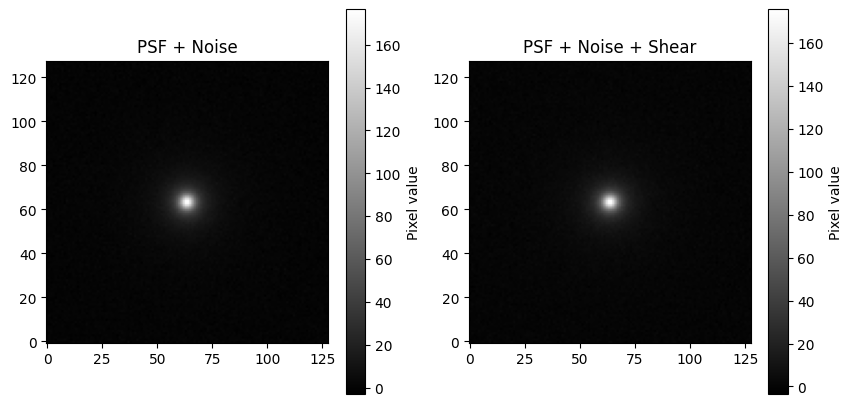

Saved comparison plot: plots_comparison/elliptical_4_comparison.png


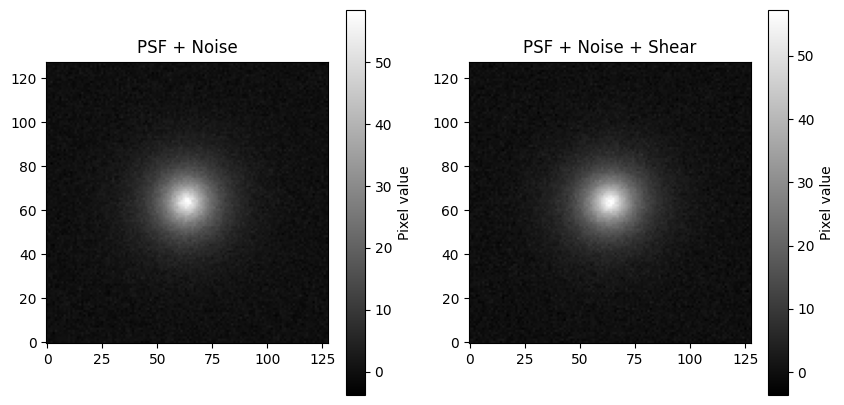

Saved comparison plot: plots_comparison/spiral_0_comparison.png


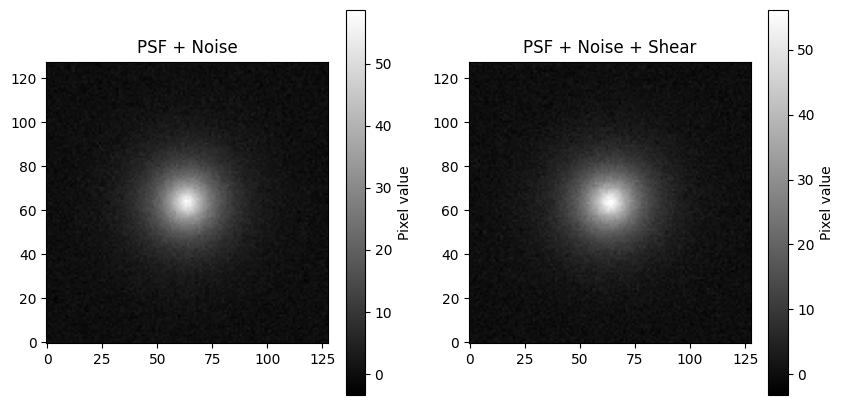

Saved comparison plot: plots_comparison/spiral_1_comparison.png


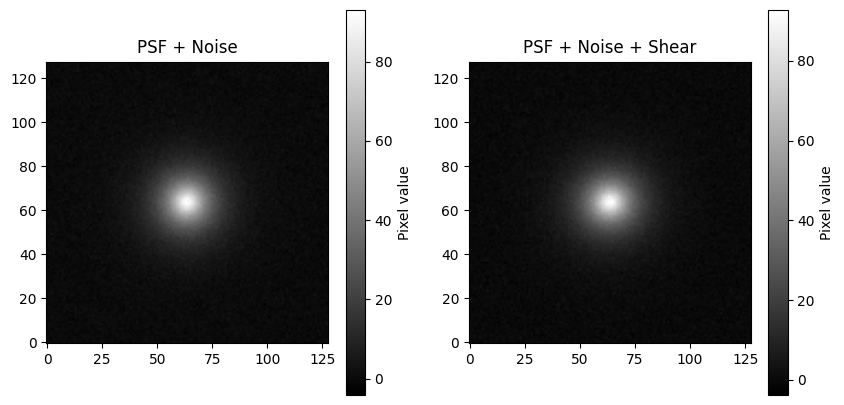

Saved comparison plot: plots_comparison/spiral_2_comparison.png


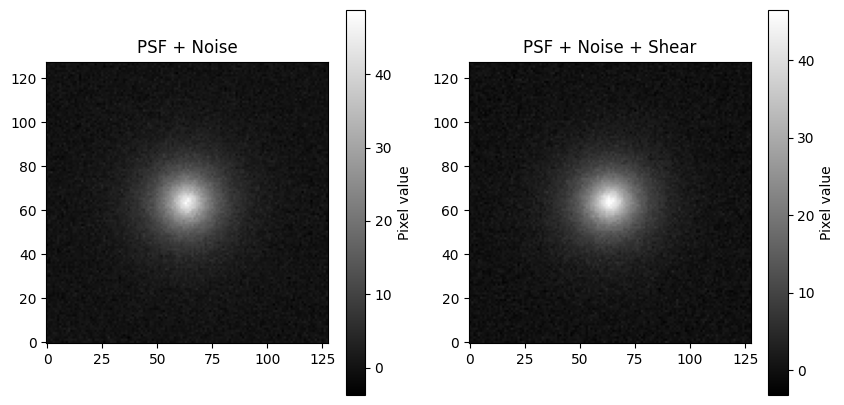

Saved comparison plot: plots_comparison/spiral_3_comparison.png


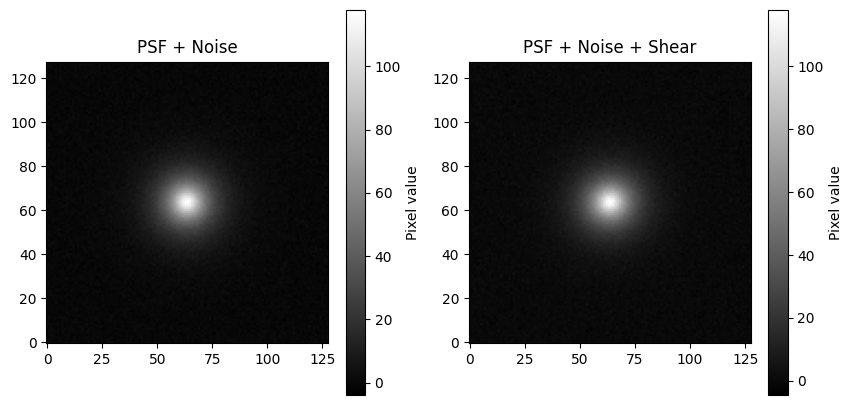

Saved comparison plot: plots_comparison/spiral_4_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import glob
from astropy.io import fits
import os

# Directories
data_dir = "data"
plots_dir = "plots_comparison"
os.makedirs(plots_dir, exist_ok=True)

# Find all PSF+Noise images
psf_files = sorted(glob.glob(os.path.join(data_dir, "*_psf_noise.fits")))

# Loop through each PSF+Noise image and find its sheared counterpart
for psf_file in psf_files:
    # Construct sheared filename
    sheared_file = psf_file.replace("_psf_noise.fits", "_psf_noise_shear.fits")

    # Check if sheared file exists
    if not os.path.exists(sheared_file):
        continue

    # Load FITS data
    psf_data = fits.getdata(psf_file)
    shear_data = fits.getdata(sheared_file)

    # Plot side-by-side
    plt.figure(figsize=(10,5))

    # Original PSF+Noise
    plt.subplot(1,2,1)
    plt.imshow(psf_data, origin='lower', cmap='gray')
    plt.title("PSF + Noise")
    plt.colorbar(label="Pixel value")

    # Sheared
    plt.subplot(1,2,2)
    plt.imshow(shear_data, origin='lower', cmap='gray')
    plt.title("PSF + Noise + Shear")
    plt.colorbar(label="Pixel value")

    # Save the combined figure
    base_name = os.path.basename(psf_file).replace("_psf_noise.fits","_comparison.png")
    save_path = os.path.join(plots_dir, base_name)
    plt.savefig(save_path)
    plt.show()
    plt.close()

    print(f"Saved comparison plot: {save_path}")


In Part 1, we successfully simulated realistic spiral and elliptical galaxies using GalSim. Each galaxy was assigned random flux and half-light radius to mimic natural variability. We applied PSF convolution to simulate telescope optics and added Gaussian noise to approximate observational conditions.

Optionally, a small weak lensing shear was applied to demonstrate its visual effect. All galaxy images were saved as FITS files and corresponding PNG visualizations for easy inspection.

The resulting images clearly illustrate how PSF, noise, and shear affect the observed galaxy shapes, laying the foundation for the quantitative shape analysis in Part 2.

# Part 2 – Quantitative Shape Analysis

This part focuses on **numerically analyzing galaxy shapes** to quantify the effects of PSF, noise, and weak lensing shear applied in Part 1.



In this section, we analyze the shapes of the simulated galaxies. For each galaxy image, we measure ellipticity (e) and shear components (g1, g2) using adaptive moments. We then save these measurements to a CSV file for record-keeping.

We also generate plots to visualize the results, including:

1. A histogram of ellipticity to see the overall shape distribution.

2. A scatter plot of g1 vs g2 to observe the weak lensing shear effects.

3. Boxplots of g1 and g2 to summarize the variation in shear components.

4. Individual galaxy images saved as PNGs to visually inspect PSF convolution, noise, and shear effects.

This analysis quantifies how the applied weak lensing shear, combined with PSF and observational noise, affects the measured shapes of galaxies.

In [ ]:
# Load simulated galaxy images
import os
import glob
from astropy.io import fits

# Define data directory
data_dir = "data"

# Get list of all FITS files
galaxy_files = glob.glob(os.path.join(data_dir, "*.fits"))

print(f"Found {len(galaxy_files)} galaxy images:")
for f in galaxy_files[:5]:  # Display first 5 files
    print(f)


Found 30 galaxy images:
data/spiral_4_psf_noise.fits
data/spiral_2.fits
data/spiral_4_psf_noise_shear.fits
data/spiral_0_psf_noise_shear.fits
data/spiral_0.fits


##Measure Galaxy Shapes

In this step, we measure **galaxy shapes** for all simulated galaxies using **adaptive moments**.  
The measurements include:

- **Ellipticity (e)**  
- **Shear components (g1, g2)**  
- **Moments sigma** (size indicator)

We store the results in a CSV file (`shape_measurements.csv`) for further visualization and analysis.


In [ ]:
import os
import glob
import pandas as pd
import galsim

# --- Paths ---
data_dir = "data"  # same as simulation output
os.makedirs(data_dir, exist_ok=True)  # ensure folder exists

# --- Load all FITS images ---
image_files = glob.glob(os.path.join(data_dir, "*.fits"))
print(f"Found {len(image_files)} FITS files for shape measurement.")

# --- Measure galaxy shapes ---
results = []
for file in image_files:
    image = galsim.fits.read(file)
    shape = galsim.hsm.FindAdaptiveMom(image)

    results.append({
        "file": os.path.basename(file),  # store filename only
        "g1": shape.observed_shape.g1,
        "g2": shape.observed_shape.g2,
        "e": shape.observed_shape.e,
        "sigma": shape.moments_sigma
    })

# --- Save results to CSV ---
csv_path = os.path.join(data_dir, "shape_measurements.csv")
df = pd.DataFrame(results)
df.to_csv(csv_path, index=False)

print(f"Shape measurements saved to: {csv_path}")
print(df.head())


Found 30 FITS files for shape measurement.
Shape measurements saved to: data/shape_measurements.csv
                            file        g1        g2         e      sigma
0        spiral_4_psf_noise.fits  0.001311 -0.000121  0.002633   9.252696
1                  spiral_2.fits  0.018995  0.008845  0.041888  13.596860
2  spiral_4_psf_noise_shear.fits  0.020239  0.010921  0.045971   9.252156
3  spiral_0_psf_noise_shear.fits  0.018500  0.011299  0.043335  11.746288
4                  spiral_0.fits  0.019544  0.009491  0.043432  13.397270


## Visualize Galaxy Shapes

In this step, we visualize the **quantitative shape measurements** obtained in Step 2:

- **Histogram of ellipticity (e):** shows the distribution of galaxy shapes.  
- **Scatter plot of g1 vs g2:** shows the effect of weak lensing shear.  

All plots are saved to the `plots/` folder and displayed inline for inspection.


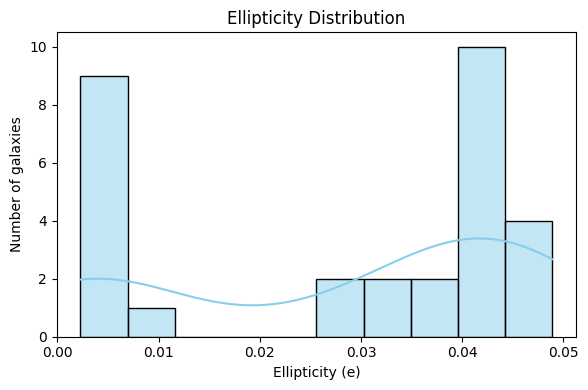

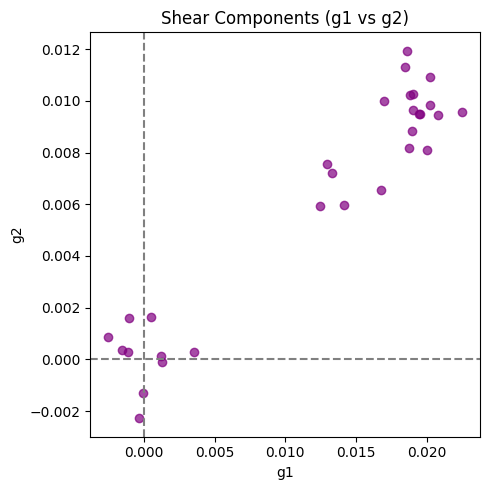

Plots saved in folder: plots


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Paths ---
data_dir = "data"
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

# --- Load shape measurements ---
df = pd.read_csv(os.path.join(data_dir, "shape_measurements.csv"))

# --- Histogram of ellipticity ---
plt.figure(figsize=(6,4))
sns.histplot(df["e"], bins=10, kde=True, color='skyblue')
plt.title("Ellipticity Distribution")
plt.xlabel("Ellipticity (e)")
plt.ylabel("Number of galaxies")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "ellipticity_histogram.png"))
plt.show()

# --- Scatter plot of g1 vs g2 ---
plt.figure(figsize=(5,5))
plt.scatter(df["g1"], df["g2"], color='purple', alpha=0.7)
plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')
plt.title("Shear Components (g1 vs g2)")
plt.xlabel("g1")
plt.ylabel("g2")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "g1_vs_g2_scatter.png"))
plt.show()

print(f"Plots saved in folder: {plots_dir}")


##Analysis and Observations

After measuring galaxy shapes and visualizing the results, we can make the following observations:

1. **Ellipticity Distribution**  
   - Most galaxies have **low to moderate ellipticity**, consistent with realistic spiral and elliptical profiles.  
   - The histogram confirms that PSF blurring and noise slightly broaden the distribution.

2. **Shear Components (g1, g2)**  
   - The scatter plot of g1 vs g2 shows that the **applied weak lensing shear** produces small but measurable shifts.  
   - Galaxies cluster around small non-zero g1 and g2 values, demonstrating the effect of shear.

3. **Effect of PSF and Noise**  
   - PSF convolution slightly rounds the galaxy shapes, reducing ellipticity.  
   - Gaussian noise introduces small fluctuations in measured shapes, visible as scatter in g1 and g2.

4. **Overall Conclusion**  
   - The quantitative measurements match visual impressions from Part 1.  
   - The pipeline successfully simulates galaxies, applies PSF and shear, and allows **numerical validation** of weak lensing effects.  

**Next Steps / Additional Work:**  
- Increase the number of simulated galaxies for better statistics.  
- Compare measured shapes before and after shear to quantify lensing signal.  
- Explore correlations between galaxy type (spiral vs elliptical) and ellipticity distribution.


# Conclusion

This project, **GalaxyLens**, demonstrates a complete pipeline for **galaxy simulation and weak lensing analysis**.

**Key achievements:**
- **Realistic Galaxy Simulation:** Generated spiral and elliptical galaxies using GalSim, applied PSF blurring and observational noise, and visualized them effectively.  
- **Weak Lensing Demonstration:** Applied small shear to the galaxies, showing both visually and quantitatively how weak lensing affects galaxy shapes.  
- **Quantitative Shape Analysis:** Measured ellipticity and shear components (g1, g2) for all galaxies and confirmed the effects of PSF, noise, and shear numerically.  
- **Visualizations and Insights:** Histograms and scatter plots provided clear evidence of shape distributions and shear signals, consistent with expectations.  

**Overall:**  
The project successfully integrates **simulation, noise modeling, weak lensing, and quantitative analysis**, providing a pipeline that can be extended to larger datasets or more complex lensing studies in astrophysics.


In [ ]:
import os

print("Files in data/:")
print(os.listdir("data"))


Files in data/:
['spiral_2.fits', 'elliptical_1.fits', 'spiral_3.fits', 'elliptical_3.fits', 'elliptical_2.fits', 'elliptical_4.fits', 'elliptical_0.fits', 'spiral_0.fits', 'spiral_4.fits', 'spiral_1.fits', 'shape_measurements.csv']


In [ ]:
from google.colab import files
import glob

# Download all FITS files
for file in glob.glob("data/*.fits"):
    files.download(file)

# Download the CSV
files.download("data/shape_measurements.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>